<a href="https://colab.research.google.com/github/sanit15/pytorch/blob/main/04_PyTorch_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. Pytorch Custom datasets

Util now we have used datasets from pytorch.

But how do we get or own data?

Using custom datasets.


## 0. importing pytorch and setting up agnostic codes.


In [84]:
import torch
from torch import nn
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 1. Getting data

our dataset is a subsetof the Food101 dataset

Food101 starts with 101 different classes if food.

Our dataset starts with 3 classes of foood and only 10% of imgs(~ 75 training, 25 testing)

Why?
When staring a ML project, its import to

In [85]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
img_path = data_path / "pizza_steak_sushi"

if img_path.is_dir():
  print(f"{img_path} directory already exists... skiping download")
else:
  print(f" {img_path} doesnt exist, Creating one...")
  img_path.mkdir(parents=True, exist_ok=True)

  #  Downloading the data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print(f" Downloading pizza, steak and sushi data")
  f.write(request.content)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print(f" Unzipping pizza, steak and sushi data")
  zip_ref.extractall(img_path)

data/pizza_steak_sushi directory already exists... skiping download
 Unzipping pizza, steak and sushi data


## 2. Becoming one with the data (data preparation and exploration)

In [86]:
import os
def walk_thru_dir(dir_path):
  """ Walks through dir_path returning its contents"""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f" There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

walk_thru_dir(img_path)

 There are 2 directories and 0 images in 'data/pizza_steak_sushi'
 There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
 There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
 There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
 There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
 There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
 There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
 There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
 There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'


In [87]:
# Setup train and test path

train_dir = img_path / "train"
test_dir = img_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and Imaging

* Get all of images of the img paths
* pick a random img ppath using Pythons random.choice()
* Get the image class name using `pathlib.Path.parent.stem`
* Since we're working with images lets open the image with Pythons PIL
* show image and print metadata


random image patth:data/pizza_steak_sushi/test/pizza/3475871.jpg
Image class: pizza
Image height: 512
Image width: 512


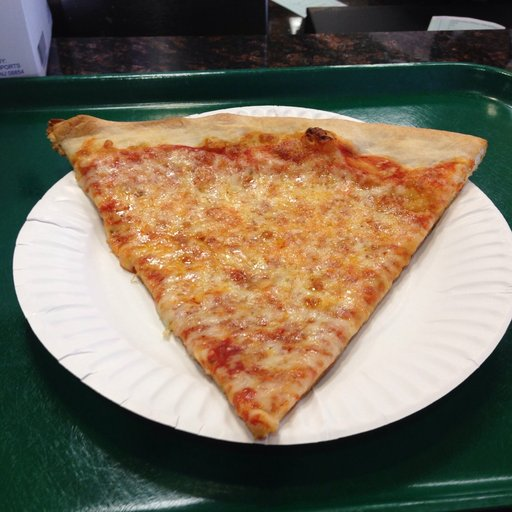

In [88]:
import random
from PIL import Image
random.seed(42)

# 1. Get all images paths
img_path_list = list(img_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_img_path = random.choice(img_path_list)

# 3. Get the image class from the path name (the img class is the name of directory where img is stored)
image_class = random_img_path.parent.stem # stem is end of the folder

# Open image
img = Image.open(random_img_path)

# 5. print metadata
print(f"random image patth:{random_img_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

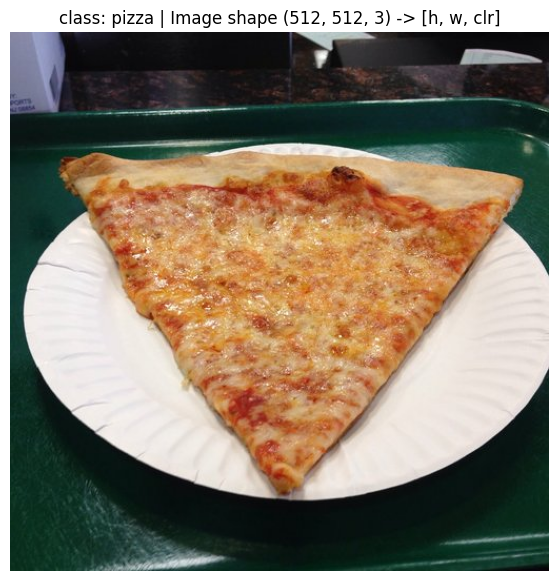

In [89]:
 # Visualize data using matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.array(img)


# plotting
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"class: {image_class} | Image shape {img_as_array.shape} -> [h, w, clr]")
plt.axis(False)

## 3. Transforming data
Before use of our images data with Pytorch:
1. Turn target data to tensors
2. turn it into a `torch.utils.data.Dataset` and subsequently turn into ` torch.utils.data.DataLoader`

In [90]:
from http.cookiejar import LoadError
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 TRANSFORMING DATA WITH `torchvision.transform`

In [91]:
# write a transform for the image
data_transform = transforms.Compose([
    # Rezise the img to ^4x^4
    transforms.Resize((64,64)),
    # Flip the images randomly on the horizaontal
    transforms.RandomHorizontalFlip(p=0.5), # 50%
    # transform image to tensor
    transforms.ToTensor() # converts pil (HxWxC) -> Tensor(CxHxW)

]

)

In [92]:
data_transform(img).shape


torch.Size([3, 64, 64])

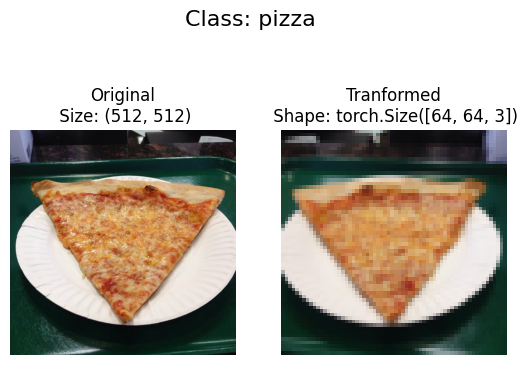

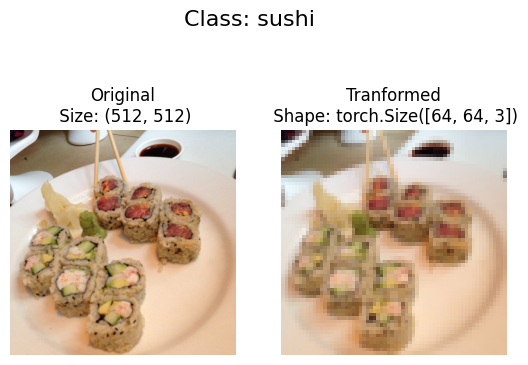

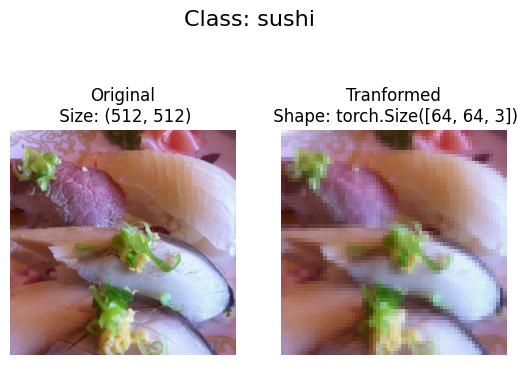

In [93]:
def plot_transformed_images(img_paths: list, transform, n = 3, seed = None):
  """
  Selects random images from a path of images and loads/transforms
  them, then plots the original vs transformed
  """
  if seed:
    random.seed(seed)
  random_img_paths = random.sample(img_paths, k = n)
  for img_path in random_img_paths:
    with Image.open(img_path) as f:
      fig, ax = plt.subplots(nrows = 1, ncols = 2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\n Size: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_img = transform(f).permute(1,2,0) # note: we will need to change shape for matplotlib, the numbers are the indices
      ax[1].imshow(transformed_img)
      ax[1].set_title(f"Tranformed\n Shape: {transformed_img.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {img_path.parent.stem}", fontsize = 16)

plot_transformed_images(img_path_list, data_transform, n = 3, seed = 42)

## 4. Option 1: Loading image data using `ImagFolder`

We can load image data using `torchvision.datasets.ImageFolder`

In [94]:
from torchvision import datasets
train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform,
                                  target_transform = None)

test_data = datasets.ImageFolder(root = test_dir, transform = data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [95]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [96]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [97]:
len(train_data), len(test_data)

(225, 75)

In [98]:
# Index on the train_data Dataset to gry a singlr image and the label
img, label = train_data[0]
print(f"image shape: {img.shape}")
print(f"label: {label}")
print(F"label datatype: {type(label)}")
print(f"class name: {class_names[label]}")

image shape: torch.Size([3, 64, 64])
label: 0
label datatype: <class 'int'>
class name: pizza


In [99]:
# rearrange the order of dimensions
img_permute = img.permute(1,2,0)
img_permute.shape

torch.Size([64, 64, 3])

Text(0.5, 1.0, 'class: pizza | shape: torch.Size([3, 64, 64])')

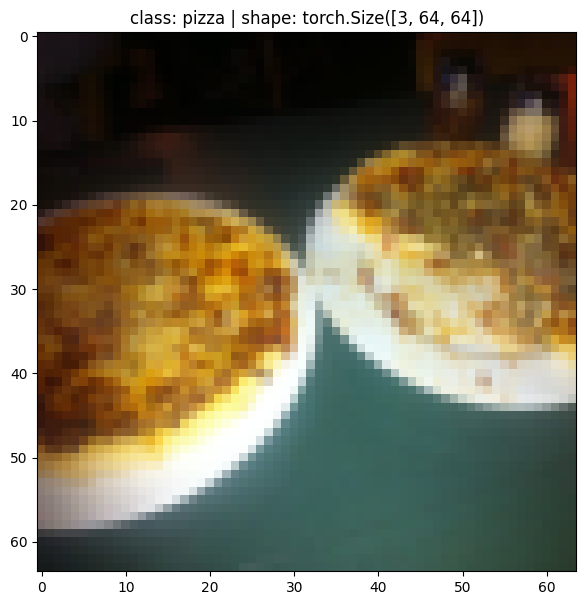

In [100]:
# plot the image
plt.figure(figsize = (10,7))
plt.imshow(img_permute)
plt.title(f"class: {class_names[label]} | shape: {img.shape}")

### 4.1 Turn dataset into dataloader

A `DataLoader` helps to turn our `Dataset` into itterable and we can customize the batchsize of images at any time

In [101]:
import os
os.cpu_count()

2

In [102]:
from torch.utils.data import DataLoader
BATCH_SIZE  = 32
train_dataloader = DataLoader(dataset = train_data,
                              shuffle = True,
                              num_workers = os.cpu_count(),
                              batch_size = BATCH_SIZE)
test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fc45a288b90>,
 <torch.utils.data.dataloader.DataLoader at 0x7fc3c87179e0>)

In [103]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [104]:
img,label = next(iter(train_dataloader))
img.shape, label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 5. Option 2: Loading image data with custom `Dataset`

1. Want to be able to load image from file
2. Want to be able to get class names from Dataset
3. Want to be able to get classes as dictionary from the Dataset

Pros:
* Can create `Dataset` out of almost anything
* Not limited tp PyTorch pre-built `Dataset`

Cons:
* Even though could create `Datasets out of almost anything, it doesnt mean it will work...
* Using a custom `Dataset` often results in us writiing more code which could be prone to errors/performance issues

In [105]:
import os
import pathlib
import tensorflow as tf

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [106]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard iimage classification format).
2. Raise an error if the class name aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dict and list and return them.

In [107]:
# Setup path for the target directory
target_dir = train_dir
print(f"Target dir: {target_dir}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_dir))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [108]:
list(os.scandir(target_dir))


[<DirEntry 'sushi'>, <DirEntry 'steak'>, <DirEntry 'pizza'>]

In [109]:
# functionizing the code to find classes
def find_classes(dir: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder names in a target directory.

  Assumes the target directory is in standard image classification
  """
  # 1. Get the class names by scanning the target directories
  classes = sorted(entry.name for entry in os.scandir(dir) if entry.is_dir())

  # 2. Raise an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Couldnt find any classes in {dir}... please check file structure.")

  # 3. Create a dictionary of index labels
  class_to_idx = {class_names: i for i, class_names in enumerate(classes)}
  return classes, class_to_idx

In [110]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Creating a custom `Dataset` to replicate `ImageFolder`

To create our own custom Dataset, we want to:

1. Subclass `torch.utils.data.Dataset`
2. Init our sublcass with a target directory (the directory we'd like to get data from) as well as transform if we'd like to transform our data
3. Create several attributes:
  * paths - paths of our images
  * transform - the transform we'd like to use
  * classes - a list of the target classes
  * class_to_idx - a dict of the ttarget classes maped to integer labels
4. Create a function to `load_images()`, this function will open an image

Note:

 All subclasses should overwrite `__getitem__()`, fetching a data sample for given

 optionally overwrite `__len__()`, expected to return size of a dataset

In [111]:
# Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  #2. Initialize our custom dataset
  def __init__(self, targ_dir: str, transform = None):
    # 3. create class attribute
    # Get all the image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transform
    self.transform = transform
    self.classes, self.class_to_idx = find_classes(targ_dir)
    # Create classes and class_to_idx attributes)
    self.classes, self.class_to_idx = find_classes(target_dir)

  # Create a function to load images
  def load_image(self, index: int) -> Image.Image:
    """
    Opens an image via path and returns it
    """
    image_path = self.paths[index]
    return Image.open(image_path)

  #5. Overwrite __len__()
  def __len__(self) -> int:
    """
    Returns the total number of samples.
    """
    return len(self.paths)

  # 6. Overwrite __getitem__() method to return a perticular item
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    """
    Returns one sample of dta, data and label  (X, y)
    """
    img = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    # Transform if necessary
    if self.transform:
      return self.transform(img), class_idx  # returns (X, y)
    else:
      img, class_idx



In [112]:
# create a transform
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [113]:
# test out ImagrFolderCustom
train_data_custom = ImageFolderCustom(train_dir, transform = train_transform)
test_data_custom = ImageFolderCustom(test_dir, transform = test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7fc45a207ef0>,
 <__main__.ImageFolderCustom at 0x7fc47499cec0>)

In [114]:
len(train_data), len(train_data_custom)

(225, 225)

In [115]:
len(test_data), len(test_data_custom)

(75, 75)

In [116]:
train_data_custom.classes, train_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [117]:
# Check for eqality between original Image Folder Dataset and ImageFolderDataset
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True


### Crreate a function to display random images

1. Take in a `Dataset` and a number of other parameters such as class names and how many to vilualize.
2. To prevent the display gettting out of hand, cap the max images to 10
3. Set random seed for reprduceability
4. Get a list of random sample indexes from the target dataset.
5. Setup matplotlib plot
6. Make sure dimensions of ourimage with matplotlib (HWC)

In [118]:
# 1. Create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  # Adjust display if  n too high
  if n > 10:
    n = 10
    display_shape = False
    print(f"For display purposes, n should be larger than 10, setting to 10 and removing shape display")

  # set the seed
  if(seed):
    random.seed(seed)

  # 4. Get random sample indexes
  random_sample_idx = random.sample(range(len(dataset)), k=n)

  plt.figure(figsize = (16,8))

  # 5. Loop thru random idx and plot them
  for i, targ_sample in enumerate(random_sample_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # 6. Adjust tensor dimension
    targ_image_adjust = targ_image.permute(1,2,0)

    # Plot
    plt.subplot(1,n,i+1)
    plt.imshow(targ_image_adjust)
    if classes:
      plt.title(f"class: {classes[targ_label]}")
      if display_shape:
        plt.title(f"class: {classes[targ_label]}\nShape: {targ_image_adjust.shape}")
    else:
      plt.title(f"class: {targ_label}")
    plt.axis(False)


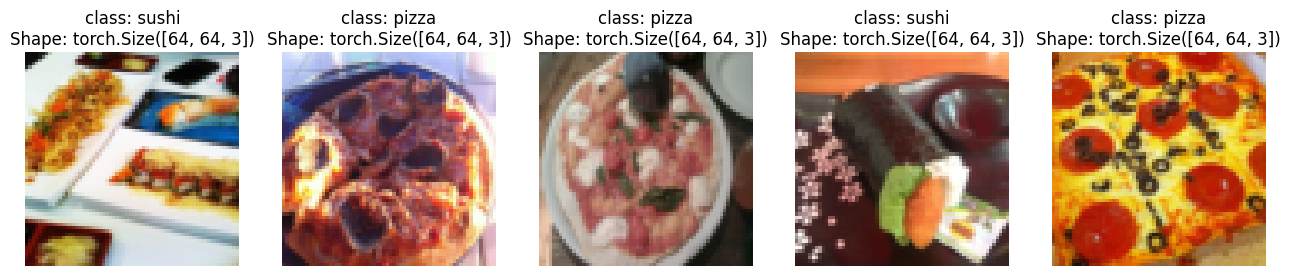

In [119]:
# Display random images from ImageFolder created Dataset
display_random_images(train_data,
                      classes = class_names,
                      n = 5, seed = 42,
                      display_shape = True)

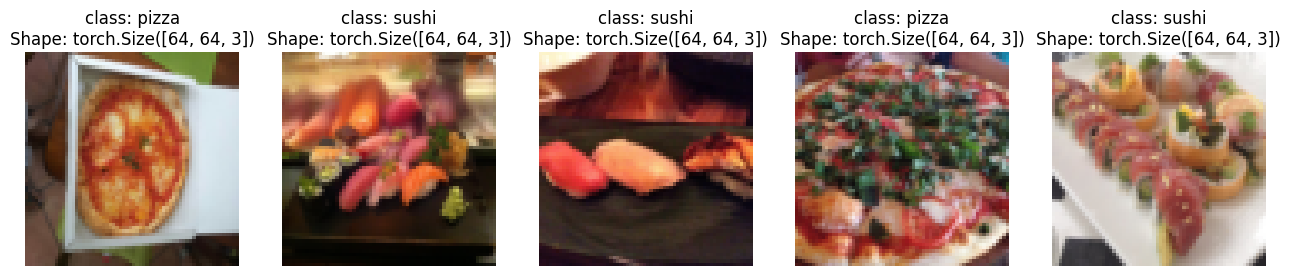

In [120]:
# Display random images from ImageFolderCustom created Dataset
display_random_images(train_data_custom,
                      classes = class_names,
                      n = 5, seed = 42)

### 5.4 Turn custom loaded images into `DataLoader`

In [121]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                  batch_size = BATCH_SIZE,
                                  shuffle = True,
                                  num_workers = os.cpu_count())
test_dataloader_custom = DataLoader(dataset = train_data_custom,
                                  batch_size = BATCH_SIZE,
                                  num_workers = 1)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7fc44e9cd4c0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fc3c3f07740>)

In [122]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Other forms of transform (data augmentation)

Data augmentation is the process of artificially adding diversity to your training data.

In the case of image data, this may mean applying various transformaions to the training images.

In [123]:
# Lets look at trivial augment
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins= 31), # scale of augmentation, max is 31
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [124]:
img_path

PosixPath('data/pizza_steak_sushi')

In [125]:
# Get all image paths
image_path_list = list(img_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/sushi/719108.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/207578.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/858157.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1230335.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2521706.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1434806.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/343036.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1600999.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1987407.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/175783.jpg')]

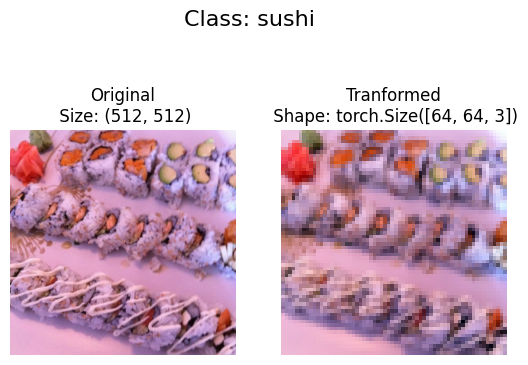

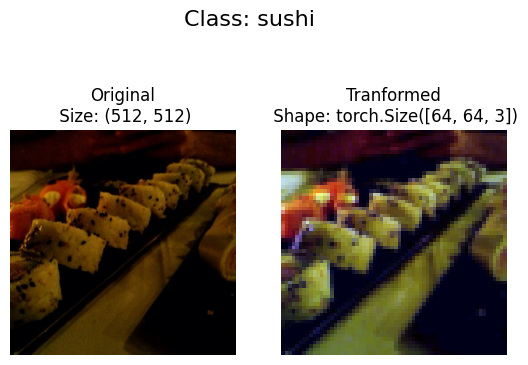

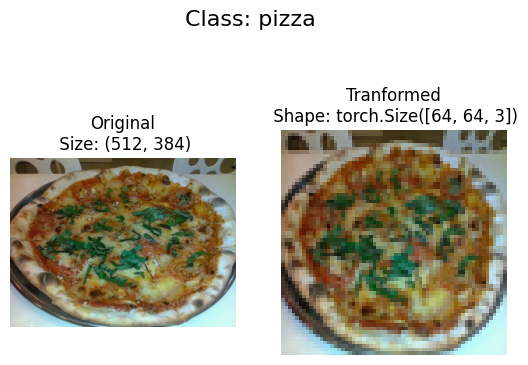

In [126]:
plot_transformed_images(img_paths = image_path_list,
                        transform = train_transforms,
                        n = 3
                        )

## 7. Model 0: TinyVGG without Data augmentation

### 7.1 Creating a simple transform and loading data for Model 0

In [203]:
simple_transform = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.ToTensor()
])

In [204]:
# 1. Load and transform data
from torchvision import datasets
from torch.utils.data import DataLoader

train_data_simple = datasets.ImageFolder(root = train_dir,
                                       transform = simple_transform,
                                       )
test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform = simple_transform,
                                       )

# 2. Turn datasets to dataloaders
import os
NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 32
train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = False,
                                     num_workers = NUM_WORKERS)

In [217]:
# 3. Creating a TinyVGG model
from torch import nn
class TinyVGG(nn.Module):
  def __init__(self, hidden_units: int,
               input_shape: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_blk_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.conv_blk_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*29*29, # multiply all the dimensions except the batch size (Batch_size, hidden_units, x, x) -> hidden_units*x*x
                  out_features = output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_blk_1(x)
    #print(x.shape)
    x = self.conv_blk_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x

In [221]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape = 3,
                  output_shape = len(class_names),
                  hidden_units = 10).to(device)
model_0

TinyVGG(
  (conv_blk_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_blk_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8410, out_features=3, bias=True)
  )
)

### 7. Try the forward pass on a single image


In [222]:
# get a single image
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [223]:
model_0(image_batch.to(device))

tensor([[ 0.0124, -0.0471, -0.0247],
        [ 0.0090, -0.0441, -0.0223],
        [ 0.0096, -0.0444, -0.0229],
        [ 0.0116, -0.0455, -0.0241],
        [ 0.0115, -0.0435, -0.0223],
        [ 0.0093, -0.0461, -0.0237],
        [ 0.0102, -0.0459, -0.0234],
        [ 0.0108, -0.0449, -0.0245],
        [ 0.0099, -0.0426, -0.0189],
        [ 0.0107, -0.0449, -0.0209],
        [ 0.0137, -0.0463, -0.0211],
        [ 0.0113, -0.0482, -0.0246],
        [ 0.0126, -0.0482, -0.0215],
        [ 0.0075, -0.0453, -0.0186],
        [ 0.0134, -0.0487, -0.0257],
        [ 0.0126, -0.0475, -0.0232],
        [ 0.0102, -0.0461, -0.0190],
        [ 0.0107, -0.0490, -0.0248],
        [ 0.0128, -0.0450, -0.0216],
        [ 0.0108, -0.0444, -0.0208],
        [ 0.0114, -0.0456, -0.0240],
        [ 0.0116, -0.0460, -0.0218],
        [ 0.0115, -0.0467, -0.0245],
        [ 0.0106, -0.0467, -0.0193],
        [ 0.0121, -0.0498, -0.0213],
        [ 0.0142, -0.0460, -0.0220],
        [ 0.0133, -0.0491, -0.0231],
 

In [224]:
16*16*16

4096

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model

In [225]:
!pip install torchinfo

In [228]:
from torchinfo import summary
summary(model_0, input_size = (1, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 62, 62]           --
│    └─Conv2d: 2-1                       [1, 10, 126, 126]         280
│    └─ReLU: 2-2                         [1, 10, 126, 126]         --
│    └─Conv2d: 2-3                       [1, 10, 124, 124]         910
│    └─ReLU: 2-4                         [1, 10, 124, 124]         --
│    └─MaxPool2d: 2-5                    [1, 10, 62, 62]           --
├─Sequential: 1-2                        [1, 10, 29, 29]           --
│    └─Conv2d: 2-6                       [1, 10, 60, 60]           910
│    └─ReLU: 2-7                         [1, 10, 60, 60]           --
│    └─Conv2d: 2-8                       [1, 10, 58, 58]           910
│    └─ReLU: 2-9                         [1, 10, 58, 58]           --
│    └─MaxPool2d: 2-10                   [1, 10, 29, 29]           --
├─Sequentia

### 7.5 Create train and test loop function

In [229]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)

    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  return train_loss, train_acc


In [230]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
  model.eval()
  with torch.inference_mode():
    test_loss, test_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred = model(X)

      loss = loss_fn(test_pred, y)

      test_loss += loss.item()

      test_pred_class = torch.argmax(torch.softmax(test_pred, dim = 1), dim=1)
      test_acc += (test_pred_class == y).sum().item()/len(test_pred)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc


### &.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [231]:
from timeit import default_timer as timer
def total_train_time(start: float, end: float, device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [232]:
from tqdm.auto import tqdm

In [233]:
def train(model: torch.nn.Module,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          device: torch.device,
          epochs: int = 5):
  start_timer = timer()
  model.to(device)
  # create emppty results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n.....")
    train_loss, train_acc = train_step(dataloader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               device = device,
               model = model)
    test_loss, test_acc = test_step(dataloader = test_dataloader,
              loss_fn = loss_fn,
              device = device,
              model = model)
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  end_timer = timer()
  total_train_time(start_timer, end_timer, device)
  return results

### 7.7 Train and evaluate model 0

In [234]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_0 = TinyVGG(
    input_shape = 3,
    hidden_units = 10,
    output_shape = len(class_names)
)

EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),
                            lr = 0.001)



model_0_results = train(model = model_0,
                        loss_fn = loss_fn,
                        optimizer = optimizer,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader = test_dataloader_simple,
                        device = device,
                        epochs = EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
.....
Train loss: 1.1479 | Train acc: 0.3008 | Test loss: 1.1321 | Test acc: 0.2604
Epoch: 1
.....
Train loss: 1.1258 | Train acc: 0.2695 | Test loss: 1.0547 | Test acc: 0.5417
Epoch: 2
.....
Train loss: 1.1118 | Train acc: 0.3086 | Test loss: 1.1104 | Test acc: 0.2604
Epoch: 3
.....
Train loss: 1.1038 | Train acc: 0.3047 | Test loss: 1.0979 | Test acc: 0.2708
Epoch: 4
.....
Train loss: 1.1125 | Train acc: 0.2695 | Test loss: 1.1204 | Test acc: 0.1979
Train time on cpu: 25.580 seconds


In [142]:
model_0_results

{'train_loss': [1.106319084763527,
  1.0998057276010513,
  1.0868544578552246,
  1.0842333287000656,
  1.0662163645029068],
 'train_acc': [0.3046875, 0.328125, 0.48828125, 0.3984375, 0.4140625],
 'test_loss': [1.0983205238978069,
  1.069690187772115,
  1.0807572205861409,
  1.0608318249384563,
  1.0653960307439168],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.5833333333333334,
  0.5643939393939394]}

### 7.8 plot the loss curve

In [143]:
# get model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [144]:
def plot_loss_curves(results: Dict[str, List[float]]):
  loss = results["train_loss"]
  test_loss = results["test_loss"]
  acc = results["train_acc"]
  test_acc = results["test_acc"]
  epochs = range(len(results["train_loss"]))

  plt.figure(figsize = (15,7))

  plt.subplot(1,2,1)
  plt.plot(epochs, loss, label = "train_loss")
  plt.plot(epochs, test_loss, label = "test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs, acc, label = "train_acc")
  plt.plot(epochs, test_acc, label = "test_acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

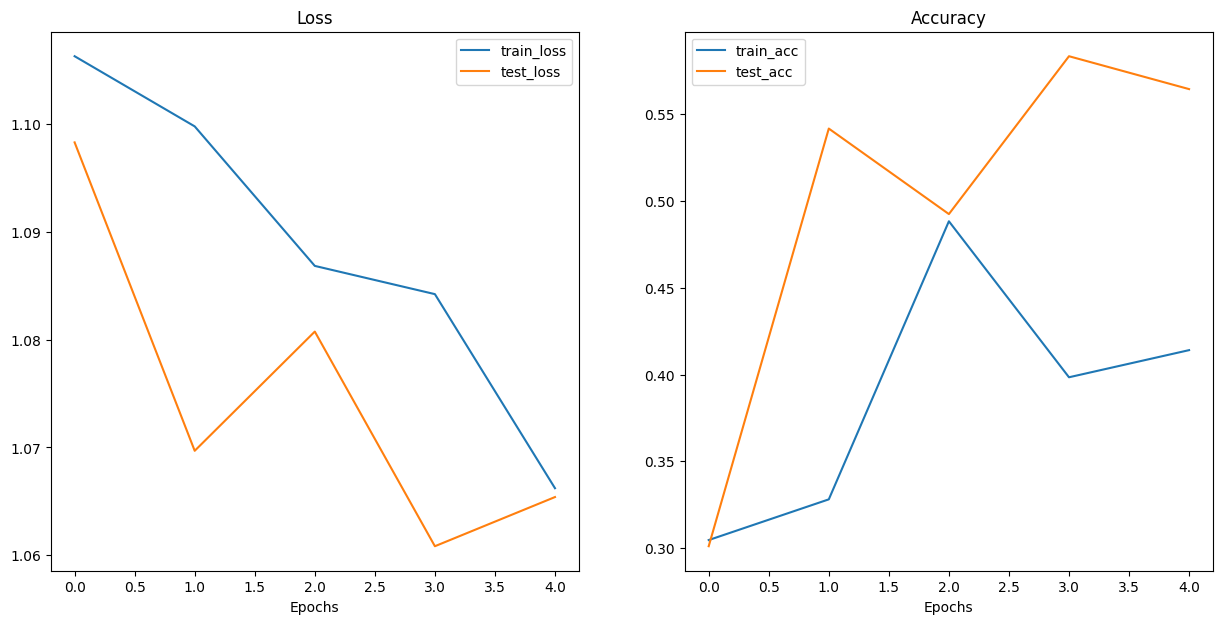

In [145]:
plot_loss_curves(model_0_results)

## 8. What should an ideal loss curve look like
https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves

## 9. Model 1: Tiny VGG with Data Augmentation

### 9.1 Create transform with TrivialAugment

In [235]:
from torchvision import transforms
train_transforms_trivial = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.TrivialAugmentWide(num_magnitude_bins= 31), # scale of augmentation, max is 31
    transforms.ToTensor()
])
test_transforms_trivial = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

### 9.1 Create `Dataset` and `DataLoader` with the augmented data

In [147]:
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root = train_dir,
                                            transform = train_transforms_trivial)
test_data_augmented = datasets.ImageFolder(root = test_dir,
                                            transform = test_transforms_trivial)

In [148]:
# turn datasets to dataloafers
import os
NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 32
train_dataloader_augmented = DataLoader(dataset = train_data_augmented,
                                     batch_size = BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS)
test_dataloader_augmented = DataLoader(dataset = test_data_augmented,
                                     batch_size = BATCH_SIZE,
                                     shuffle = False,
                                     num_workers = NUM_WORKERS)

### 9.3 Construct and train model 1

this time we'll use same model architecure but with augmented data

In [149]:
torch.manual_seed(42)
model_1 = TinyVGG(input_shape = 3,
                   hidden_units =10,
                   output_shape = len(class_names)).to(device)
model_1

TinyVGG(
  (conv_blk_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_blk_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [150]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),
                            lr = 0.001)



model_1_results = train(model = model_1,
                        loss_fn = loss_fn,
                        optimizer = optimizer,
                        train_dataloader = train_dataloader_augmented,
                        test_dataloader = test_dataloader_augmented,
                        device = device,
                        epochs = EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
.....
Train loss: 1.1049 | Train acc: 0.2500 | Test loss: 1.1019 | Test acc: 0.2604
Epoch: 1
.....
Train loss: 1.0807 | Train acc: 0.4258 | Test loss: 1.1261 | Test acc: 0.2604
Epoch: 2
.....
Train loss: 1.0712 | Train acc: 0.4258 | Test loss: 1.1593 | Test acc: 0.2604
Epoch: 3
.....
Train loss: 1.1253 | Train acc: 0.3047 | Test loss: 1.1581 | Test acc: 0.2604
Epoch: 4
.....
Train loss: 1.0865 | Train acc: 0.4258 | Test loss: 1.1554 | Test acc: 0.3333
Train time on cpu: 19.145 seconds


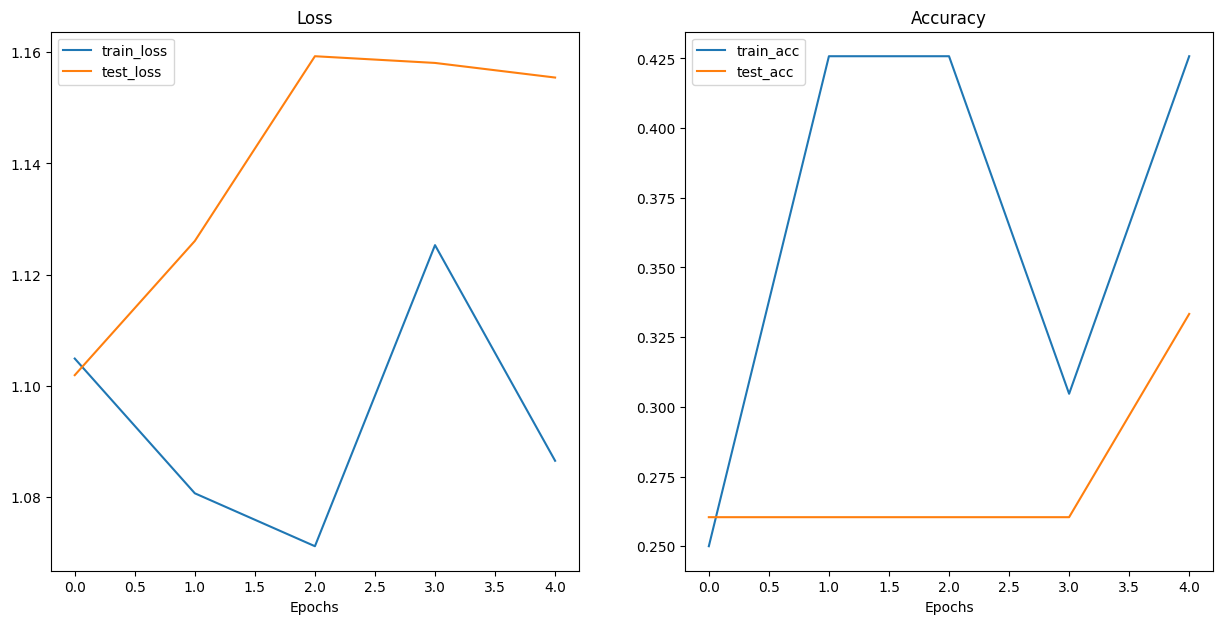

In [151]:
plot_loss_curves(model_1_results)

## 10. Compare model results

In [152]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106319,0.304688,1.098321,0.301136
1,1.099806,0.328125,1.069690,0.541667
2,1.086854,0.488281,1.080757,0.492424
3,1.084233,0.398438,1.060832,0.583333
4,1.066216,0.414062,1.065396,0.564394


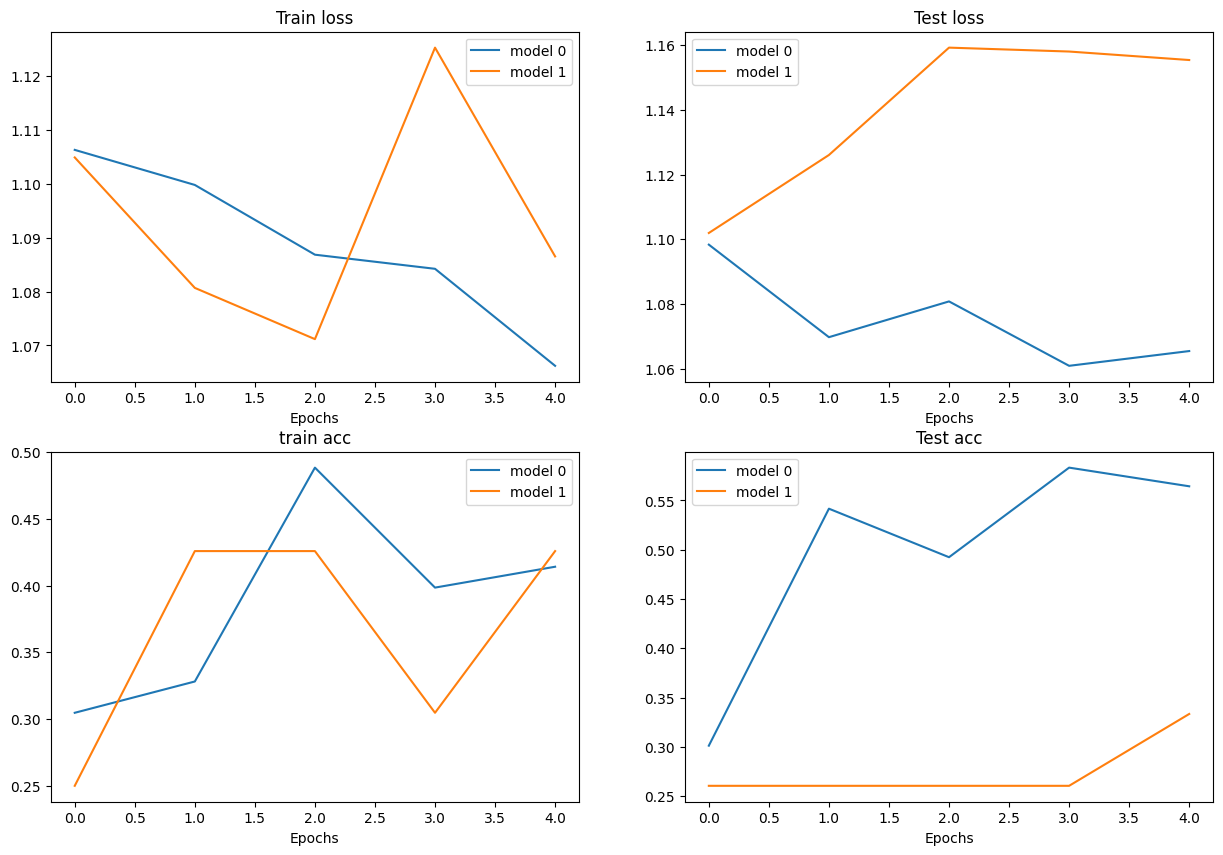

In [153]:
# setup a plot
plt.figure(figsize = (15,10))

epochs = range(len(model_0_df))

plt.subplot(2,2,1)
plt.plot(epochs, model_0_df["train_loss"], label = "model 0")
plt.plot(epochs, model_1_df["train_loss"], label = "model 1")
plt.title("Train loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs, model_0_df["test_loss"], label = "model 0")
plt.plot(epochs, model_1_df["test_loss"], label = "model 1")
plt.title("Test loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,3)
plt.plot(epochs, model_0_df["train_acc"], label = "model 0")
plt.plot(epochs, model_1_df["train_acc"], label = "model 1")
plt.title("train acc")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs, model_0_df["test_acc"], label = "model 0")
plt.plot(epochs, model_1_df["test_acc"], label = "model 1")
plt.title("Test acc")
plt.xlabel("Epochs")
plt.legend()

## 11. Making a prediciton on a custom image

In [154]:
# Download custom image
import requests

custom_image_path = data_path / "04-pizza-dad.jpeg"

if not custom_image_path.exists():
  with open(custom_image_path, "wb") as f:
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")

    print(f"Downloading {custom_image_path}...")
    f.write(request.content)
else:
  print("already exists")

already exists


### 11.1 Loading in a custom images in the same format as the sata our model was trained on

* In tensor form with datatype
* Of shape 64x64
* On the right device

In [155]:
custom_image_path

PosixPath('data/04-pizza-dad.jpeg')

In [156]:
import torchvision
custom_image_uint8 = torchvision.io.read_image(custom_image_path)
print(f"custom_image_uint8: {custom_image_uint8}")
print(f"custom_image_uint8.shape: {custom_image_uint8.shape}")
print(f"custom_image_uint8.dtype: {custom_image_uint8.dtype}")

custom_image_uint8: tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)
custom_image_uint8.shape: torch.Size([3, 4032, 3024])
custom_image_

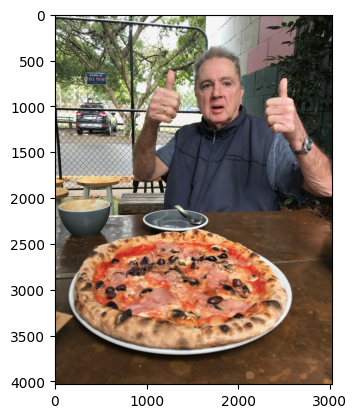

In [157]:
plt.imshow(custom_image_uint8.permute(1,2,0))

### 11.2 Making a prediction on a custom image with a trained PyTorch model

In [158]:
model_1.eval()

custom_image = custom_image_uint8.type(torch.float32).to(device)
custom_image = custom_image/255. # max color value is 255



In [159]:
custom_image

tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..., 0.0549, 0.0510, 0.

In [162]:
# create transform transform
custom_image_transform = transforms.Compose({
    transforms.Resize((64, 64))
})
custom_image_transformed = custom_image_transform(custom_image)
custom_image_transformed.shape

torch.Size([3, 64, 64])

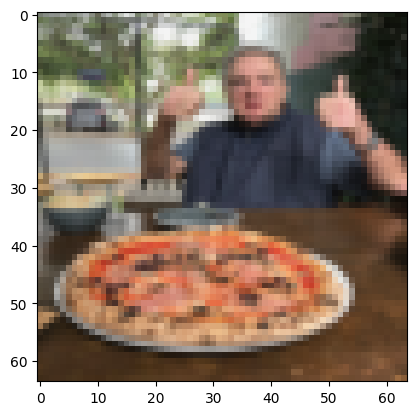

In [163]:
plt.imshow(custom_image_transformed.permute(1,2,0))

In [171]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim = 0).to(device))
custom_image_pred

tensor([[ 0.0781,  0.0379, -0.2067]])

In [172]:
custom_image_transformed.unsqueeze(dim = 0).shape

torch.Size([1, 3, 64, 64])

In [176]:
ypred = torch.argmax(torch.softmax(custom_image_pred, dim = 1), dim = 1).cpu()
ypred

tensor([0])

In [177]:
class_names[ypred]

'pizza'

### 11.3 Putting custom image prediciton together: building a function

Ideal outcome:

A function where we pass an image path to and have our model predict on the image and plot the image + predicition

In [201]:

def plot_and_predict(model: torch.nn.Module,
                     image_path: str,
                     class_names: List[str] = None,
                     transform = None,
                     device = device):
  """
  Makes a prediction on a target image with a trained model and plot the image and prediction.
  """
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # Divide the image pixel values by 255 i.e. Normalize the data,
  target_image = target_image/255.
  if transform:
    target_image = transform(target_image)

  model.to(device)
  model.eval()
  with torch.inference_mode():
    target_image_pred = model(target_image.unsqueeze(dim = 0).to(device))

  target_image_pred_probs = torch.softmax(target_image_pred, dim = 1)
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim = 1)


  plt.imshow(target_image.permute(1,2,0))
  plt.title(f"Pred: {class_names[target_image_pred_label.cpu().item()]} | Prob: {target_image_pred_probs.max():.3f}")

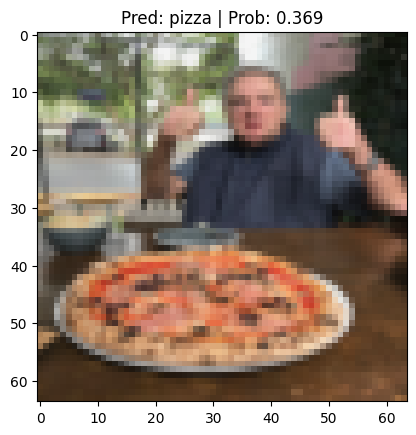

In [202]:
plot_and_predict(model_1, custom_image_path,
                 class_names = class_names,
                 transform = custom_image_transform,
                 device = device)